In [ ]:
import gc, torch
gc.collect()
torch.cuda.empty_cache()

!pip install vllm --pre --extra-index-url https://wheels.vllm.ai/nightly -q


✅ PyTorch: 2.11.0+cu130
✅ vLLM: 0.20.0


In [ ]:
import gc, torch
from vllm import LLM, SamplingParams
import time
import pandas as pd
import numpy as np

In [ ]:
draft_model = "Qwen/Qwen2.5-0.5B-Instruct"
num_speculative_tokens = 3
method = "draft_model"

llm_config = {
    "model": "Qwen/Qwen2.5-1.5B-Instruct",
    "max_model_len": 128,
    "gpu_memory_utilization": 0.85,
    "enforce_eager": True,
    "dtype": "float16",
    "tensor_parallel_size": 1,
    "disable_log_stats": False
}
llm_config["speculative_config"] = {
    "model": draft_model,
    "num_speculative_tokens": num_speculative_tokens,
    "method": method
}

gc.collect()
torch.cuda.empty_cache()

llm = LLM(**llm_config)

start_time = time.time()
outputs = llm.generate(prompts, sampling_params)
end_time = time.time()
elapsed_time = end_time - start_time

metrics = llm.llm_engine.get_metrics()
metrics_dict = {m.name: m for m in metrics if 'vllm:' in m.name}
num_generated_tokens = sum(len(output.outputs[0].token_ids) for output in outputs)
latency_ms_per_token = (elapsed_time * 1000 / num_generated_tokens) if num_generated_tokens > 0 else 0.0
num_drafts_metric = metrics_dict.get('vllm:spec_decode_num_drafts')
num_drafts = num_drafts_metric.value if num_drafts_metric else 0
num_draft_tokens_metric = metrics_dict.get('vllm:spec_decode_num_draft_tokens')
num_draft_tokens = num_draft_tokens_metric.value if num_draft_tokens_metric else 0
num_accepted_tokens_metric = metrics_dict.get('vllm:spec_decode_num_accepted_tokens')
num_accepted_tokens = num_accepted_tokens_metric.value if num_accepted_tokens_metric else 0
avg_acceptance_length = (num_accepted_tokens / num_drafts) if num_drafts > 0 else 0.0
draft_gen_speed_tokens_per_sec = (num_draft_tokens / elapsed_time) if elapsed_time > 0 else 0.0

iteration_result = {
    "Experiment": "test",
    "Draft Model": draft_model if draft_model else "N/A (Baseline)",
    "Total Time (s)": elapsed_time,
    "Generated Tokens": num_generated_tokens,
    "Latency (ms/token)": latency_ms_per_token,
    "Num Drafts": num_drafts,
    "Num Draft Tokens": num_draft_tokens,
    "Num Accepted Tokens": num_accepted_tokens,
    "Avg Acceptance Length": avg_acceptance_length,
    "Draft Gen Speed (tokens/s)": draft_gen_speed_tokens_per_sec
}

del llm
gc.collect()
torch.cuda.empty_cache()

INFO 04-26 10:06:05 [utils.py:233] non-default args: {'dtype': 'float16', 'max_model_len': 128, 'gpu_memory_utilization': 0.85, 'enforce_eager': True, 'speculative_config': {'model': 'Qwen/Qwen2.5-0.5B-Instruct', 'num_speculative_tokens': 3, 'method': 'draft_model'}, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}
INFO 04-26 10:06:06 [model.py:554] Resolved architecture: Qwen2ForCausalLM
WARNING 04-26 10:06:06 [model.py:2014] Casting torch.bfloat16 to torch.float16.
INFO 04-26 10:06:06 [model.py:1676] Using max model len 128
INFO 04-26 10:06:06 [model.py:554] Resolved architecture: Qwen2ForCausalLM
WARNING 04-26 10:06:06 [model.py:2014] Casting torch.bfloat16 to torch.float16.
INFO 04-26 10:06:06 [model.py:1676] Using max model len 32768
WARNING 04-26 10:06:06 [vllm.py:896] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-26 10:06:06 [vllm.py:914] Inductor compilation was disabled by user settings, optimiza

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [ ]:
iteration_result

{'Experiment': 'test',
 'Draft Model': 'Qwen/Qwen2.5-0.5B-Instruct',
 'Total Time (s)': 3.376326560974121,
 'Generated Tokens': 50,
 'Latency (ms/token)': 67.52653121948242,
 'Num Drafts': 40,
 'Num Draft Tokens': 120,
 'Num Accepted Tokens': 9,
 'Avg Acceptance Length': 0.225,
 'Draft Gen Speed (tokens/s)': 35.54158575389052}

## Проверка токенизаторов

In [ ]:
from transformers import AutoTokenizer

tok_main = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-1.5B-Instruct")
tok_draft_fp16 = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")
tok_draft_gptq = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4")

print(f"Main Vocab: {len(tok_main)}, Draft FP16 Vocab: {len(tok_draft_fp16)}, Draft GPTQ Vocab: {len(tok_draft_gptq)}")

test_text = "Привет, мир!"
ids_main = tok_main.encode(test_text)
ids_gptq = tok_draft_gptq.encode(test_text)
ids_draft = tok_draft_fp16.encode(test_text)

if ids_main == ids_gptq and ids_main == ids_draft:
    print("Токенизаторы идентичны.")
else:
    print(f"РАСХОЖДЕНИЕ! Main: {ids_main}, 0.5B: {ids_draft}, GPTQ: {ids_gptq}")

Main Vocab: 151665, Draft FP16 Vocab: 151665, Draft GPTQ Vocab: 151665
✅ Токенизаторы идентичны.


## Общий эксперимент

In [12]:
import gc, torch
from vllm import LLM, SamplingParams
import time
import pandas as pd
import numpy as np
from datasets import load_dataset
import subprocess

gc.collect()
torch.cuda.empty_cache()

print(f"GPU: {torch.cuda.get_device_name(0)} | VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

dataset = load_dataset("zzzhr97/SpecBench")

prompts_by_category = {}
for split_name in dataset:
    category_prompts = []
    for item in dataset[split_name]:
        category_prompts.append(item['prompt'])
    prompts_by_category[split_name] = category_prompts

print(f"Loaded {sum(len(v) for v in prompts_by_category.values())} prompts across {len(prompts_by_category)} categories.")


main_model_name = "Qwen/Qwen2.5-1.5B-Instruct"
sampling_params = SamplingParams(max_tokens=50, temperature=0.7, top_p=0.9)

global_max_model_len = 350
global_gpu_memory_utilization = 0.7
global_enforce_eager = True
global_dtype = "float16"

def run_experiment(
    llm_instance: LLM,
    config_details: dict,
    vram_smi_gb: float,
    prompts_list: list = None,
    sampling_params: SamplingParams = None,
    experiment_name: str = "Experiment",
    num_runs_per_config: int = 1,
    category_name_for_results: str = ""
):
    print(f"Starting experiment: {experiment_name}")

    main_model_name_log = config_details["main_model_name_for_logging"]
    draft_model_log = config_details.get("draft_model")
    num_speculative_tokens_log = config_details.get("num_speculative_tokens", 0 if not draft_model_log else 5)
    max_model_len_for_prompts = config_details.get("max_model_len_for_prompts", global_max_model_len)

    prompts_list = [prompt[:max_model_len_for_prompts-50] for prompt in prompts_list]

    all_prompt_results = []
    llm = llm_instance

    for i in range(num_runs_per_config):
        print(f"  Iteration {i+1}/{num_runs_per_config}")

        start_time_batch = time.time()
        outputs = llm.generate(prompts_list, sampling_params, use_tqdm=True)
        end_time_batch = time.time()
        total_batch_time = end_time_batch - start_time_batch

        metrics_vllm_engine = llm.llm_engine.get_metrics()
        metrics_dict_vllm = {m.name: m for m in metrics_vllm_engine if 'vllm:' in m.name}

        num_drafts = metrics_dict_vllm.get('vllm:spec_decode_num_drafts').value if metrics_dict_vllm.get('vllm:spec_decode_num_drafts') else 0
        num_draft_tokens = metrics_dict_vllm.get('vllm:spec_decode_num_draft_tokens').value if metrics_dict_vllm.get('vllm:spec_decode_num_draft_tokens') else 0
        num_accepted_tokens_total = metrics_dict_vllm.get('vllm:spec_decode_num_accepted_tokens').value if metrics_dict_vllm.get('vllm:spec_decode_num_accepted_tokens') else 0

        avg_acceptance_length_batch = (num_accepted_tokens_total / num_drafts) if num_drafts > 0 else 0.0
        draft_gen_speed_tokens_per_sec_batch = (num_draft_tokens / total_batch_time) if total_batch_time > 0 else 0.0
        acceptance_rate_batch = (num_accepted_tokens_total / num_draft_tokens) * 100 if num_draft_tokens > 0 else 0.0

        for idx, output in enumerate(outputs):
            prompt_text = output.prompt
            generated_text = output.outputs[0].text
            num_generated_tokens_per_prompt = len(output.outputs[0].token_ids)

            request_first_token_time = output.metrics.first_token_ts
            request_last_token_time = output.metrics.last_token_ts

            total_time_s_per_prompt = request_last_token_time - request_first_token_time if request_first_token_time and request_last_token_time else 0.0
            latency_ms_per_token_per_prompt = (total_time_s_per_prompt * 1000 / num_generated_tokens_per_prompt) if num_generated_tokens_per_prompt > 0 else 0.0
            main_model_gen_speed_tokens_per_sec_per_prompt = (num_generated_tokens_per_prompt / total_time_s_per_prompt) if total_time_s_per_prompt > 0 else 0.0

            prompt_result = {
                "Experiment": f"{experiment_name} (Iteration {i+1})",
                "Prompt Index": idx,
                "Prompt": prompt_text,
                "Main Model": main_model_name_log,
                "Draft Model": draft_model_log if draft_model_log else "N/A (Baseline)",
                "Num Speculative Tokens": num_speculative_tokens_log,
                "VRAM smi (GB)": vram_smi_gb,
                "Total Time (s)": total_time_s_per_prompt,
                "Latency (ms/token)": latency_ms_per_token_per_prompt,
                "Num Drafts": num_drafts,
                "Num Draft Tokens": num_draft_tokens,
                "Num Accepted Tokens": num_accepted_tokens_total,
                "Avg Acceptance Length": avg_acceptance_length_batch,
                "Acceptance rate": acceptance_rate_batch,
                "Draft Gen Speed (tokens/s)": draft_gen_speed_tokens_per_sec_batch,
                "Main Model Gen Speed (tokens/s)": main_model_gen_speed_tokens_per_sec_per_prompt,
                "Generated Output": generated_text,
                "Category": category_name_for_results
            }
            all_prompt_results.append(prompt_result)

    return all_prompt_results

experiment_configs = []

experiment_configs.append(
    {
        "name": "Baseline (No Speculative Decoding)",
        "draft_model": None,
        "num_speculative_tokens": 0 # Not applicable
    }
)

for n_spec_tokens in [2, 3, 4, 5]:
    experiment_configs.append(
        {
            "name": f"Speculative Decoding (Int8, {n_spec_tokens} tokens)",
            "draft_model": "Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int8",
            "num_speculative_tokens": n_spec_tokens
        }
    )

for n_spec_tokens in [2, 3, 4, 5]:
    experiment_configs.append(
        {
            "name": f"Speculative Decoding (Int4, {n_spec_tokens} tokens)",
            "draft_model": "Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4",
            "num_speculative_tokens": n_spec_tokens
        }
    )

all_results_df_list = []
num_runs_per_config_iteration = 1

for config in experiment_configs:
    print(f"\n--- Loading Model for: {config['name']} ---")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    llm_config = {
        "model": main_model_name,
        "max_model_len": global_max_model_len,
        "gpu_memory_utilization": global_gpu_memory_utilization,
        "enforce_eager": global_enforce_eager,
        "dtype": global_dtype,
        "tensor_parallel_size": 1,
        "disable_log_stats": False,
        "enable_prefix_caching": False,
        "max_num_seqs": 64,
    }

    current_draft_model = config.get("draft_model")
    if current_draft_model:
        llm_config["speculative_config"] = {
            "model": current_draft_model,
            "num_speculative_tokens": config.get("num_speculative_tokens"),
            "method": "draft_model"
        }
        print(f"Main Model: {main_model_name}, Draft Model: {current_draft_model} (dtype={llm_config['dtype']}, num_spec_tokens={config.get('num_speculative_tokens')})")
    else:
        print(f"Main Model: {main_model_name}, Speculative Decoding: DISABLED (Baseline), (dtype={llm_config['dtype']})")

    llm = LLM(**llm_config)

    if prompts_by_category:
        first_category_prompts_list = next(iter(prompts_by_category.values()))
        if first_category_prompts_list:
            warmup_prompt = first_category_prompts_list[0][:global_max_model_len-50]
            _ = llm.generate([warmup_prompt], SamplingParams(max_tokens=10))
    torch.cuda.synchronize()

    result = subprocess.run(['nvidia-smi', '--query-gpu=memory.used', '--format=csv,nounits,noheader'], stdout=subprocess.PIPE)
    vram_used_mb = float(result.stdout.decode('utf-8').strip())
    vram_smi_gb = vram_used_mb / 1024
    print(f"✅ VRAM Used (nvidia-smi) for this config: {vram_smi_gb:.2f} GB")

    for category_name, prompts_for_category in prompts_by_category.items():
        print(f"\n====== Running: {config['name']} for Category: {category_name} ======")

        current_config_details_for_logging = {
            "main_model_name_for_logging": main_model_name,
            "draft_model": config.get("draft_model"),
            "num_speculative_tokens": config.get("num_speculative_tokens", 0 if not current_draft_model else 5),
            "max_model_len_for_prompts": global_max_model_len
        }

        results_for_category_config = run_experiment(
            llm_instance=llm,
            config_details=current_config_details_for_logging,
            vram_smi_gb=vram_smi_gb,
            prompts_list=prompts_for_category,
            sampling_params=sampling_params,
            experiment_name=f"{config['name']} - {category_name}",
            num_runs_per_config=num_runs_per_config_iteration,
            category_name_for_results=category_name
        )
        all_results_df_list.extend(results_for_category_config)


    del llm
    gc.collect()
    torch.cuda.empty_cache()

final_results_df = pd.DataFrame(all_results_df_list)

numeric_cols = final_results_df.select_dtypes(include=[np.number]).columns
final_results_df[numeric_cols] = final_results_df[numeric_cols].round(2)

GPU: Tesla T4 | VRAM: 15.6 GB
Loaded 1500 prompts across 5 categories.

--- Loading Model for: Baseline (No Speculative Decoding) ---
Main Model: Qwen/Qwen2.5-1.5B-Instruct, Speculative Decoding: DISABLED (Baseline), (dtype=float16)
INFO 04-27 12:18:12 [utils.py:233] non-default args: {'dtype': 'float16', 'max_model_len': 350, 'enable_prefix_caching': False, 'gpu_memory_utilization': 0.7, 'max_num_seqs': 64, 'enforce_eager': True, 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}
INFO 04-27 12:18:13 [model.py:555] Resolved architecture: Qwen2ForCausalLM
WARNING 04-27 12:18:13 [model.py:2018] Casting torch.bfloat16 to torch.float16.
INFO 04-27 12:18:13 [model.py:1680] Using max model len 350
WARNING 04-27 12:18:13 [vllm.py:896] Enforce eager set, disabling torch.compile and CUDAGraphs. This is equivalent to setting -cc.mode=none -cc.cudagraph_mode=none
WARNING 04-27 12:18:13 [vllm.py:914] Inductor compilation was disabled by user settings, optimizations settings that are only active during inducto

Rendering prompts:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

✅ VRAM Used (nvidia-smi) for this config: 10.66 GB

====== Running: Baseline (No Speculative Decoding) for Category: Biochem ======
Starting experiment: Baseline (No Speculative Decoding) - Biochem
  Iteration 1/1


Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/300 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

INFO 04-27 12:45:11 [loggers.py:271] Engine 000: Avg prompt throughput: 266.8 tokens/s, Avg generation throughput: 383.8 tokens/s, Running: 62 reqs, Waiting: 187 reqs, GPU KV cache usage: 2.4%, Prefix cache hit rate: 0.0%
INFO 04-27 12:45:11 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 1.70, Accepted throughput: 156.84 tokens/s, Drafted throughput: 1114.59 tokens/s, Accepted: 1595 tokens, Drafted: 11335 tokens, Per-position acceptance rate: 0.342, 0.172, 0.094, 0.056, 0.040, Avg Draft acceptance rate: 14.1%
INFO 04-27 12:45:21 [loggers.py:271] Engine 000: Avg prompt throughput: 207.9 tokens/s, Avg generation throughput: 449.5 tokens/s, Running: 61 reqs, Waiting: 94 reqs, GPU KV cache usage: 2.3%, Prefix cache hit rate: 0.0%
INFO 04-27 12:45:21 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 1.71, Accepted throughput: 186.01 tokens/s, Drafted throughput: 1313.35 tokens/s, Accepted: 1883 tokens, Drafted: 13295 tokens, Per-position acceptance rate: 0.357, 

Rendering prompts:   0%|          | 0/300 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/300 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

INFO 04-27 12:45:41 [loggers.py:271] Engine 000: Avg prompt throughput: 157.9 tokens/s, Avg generation throughput: 237.5 tokens/s, Running: 64 reqs, Waiting: 235 reqs, GPU KV cache usage: 2.0%, Prefix cache hit rate: 0.0%
INFO 04-27 12:45:41 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 1.45, Accepted throughput: 72.54 tokens/s, Drafted throughput: 806.65 tokens/s, Accepted: 737 tokens, Drafted: 8195 tokens, Per-position acceptance rate: 0.263, 0.101, 0.046, 0.026, 0.014, Avg Draft acceptance rate: 9.0%
INFO 04-27 12:45:51 [loggers.py:271] Engine 000: Avg prompt throughput: 188.3 tokens/s, Avg generation throughput: 445.7 tokens/s, Running: 64 reqs, Waiting: 164 reqs, GPU KV cache usage: 2.7%, Prefix cache hit rate: 0.0%
INFO 04-27 12:45:51 [metrics.py:101] SpecDecoding metrics: Mean acceptance length: 1.68, Accepted throughput: 180.47 tokens/s, Drafted throughput: 1318.38 tokens/s, Accepted: 1835 tokens, Drafted: 13405 tokens, Per-position acceptance rate: 0.358, 0.16

In [14]:
final_results_df[final_results_df["Draft Model"] == "Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int8"]["Avg Acceptance Length"].describe()

,Avg Acceptance Length
count,6000.000000
mean,0.603500
std,0.099972
min,0.450000
25%,0.527500
50%,0.590000
75%,0.652500
max,0.850000


In [15]:
final_results_df[final_results_df["Draft Model"] == "Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4"]["Avg Acceptance Length"].describe()

,Avg Acceptance Length
count,6000.000000
mean,0.555000
std,0.065846
min,0.440000
25%,0.520000
50%,0.550000
75%,0.585000
max,0.700000


In [16]:
final_results_df

,Experiment,Prompt Index,Prompt,Main Model,Draft Model,Num Speculative Tokens,VRAM smi (GB),Total Time (s),Latency (ms/token),Num Drafts,Num Draft Tokens,Num Accepted Tokens,Avg Acceptance Length,Acceptance rate,Draft Gen Speed (tokens/s),Main Model Gen Speed (tokens/s),Generated Output,Category
0,Baseline (No Speculative Decoding) - Biochem (...,0,"Explain the protocols for the serial dilution,...",Qwen/Qwen2.5-1.5B-Instruct,N/A (Baseline),0,10.66,1.66,33.23,0,0,0,0.00,0.00,0.0,30.10,Brucella melitensis is a Gram-negative bacter...,Biochem
1,Baseline (No Speculative Decoding) - Biochem (...,1,Develop a comprehensive laboratory exercise on...,Qwen/Qwen2.5-1.5B-Instruct,N/A (Baseline),0,10.66,1.66,33.17,0,0,0,0.00,0.00,0.0,30.15,This exercise should include detailed instruc...,Biochem
2,Baseline (No Speculative Decoding) - Biochem (...,2,Compose instructions for the preparation and u...,Qwen/Qwen2.5-1.5B-Instruct,N/A (Baseline),0,10.66,1.66,33.17,0,0,0,0.00,0.00,0.0,30.15,Selective media for isolating Neisseria gonor...,Biochem
3,Baseline (No Speculative Decoding) - Biochem (...,3,Generate an in-depth guide for isolating and c...,Qwen/Qwen2.5-1.5B-Instruct,N/A (Baseline),0,10.66,1.66,33.17,0,0,0,0.00,0.00,0.0,30.15,"Include information on sample collection, pro...",Biochem
4,Baseline (No Speculative Decoding) - Biochem (...,4,"Explain the necessary precautions, materials, ...",Qwen/Qwen2.5-1.5B-Instruct,N/A (Baseline),0,10.66,1.66,33.17,0,0,0,0.00,0.00,0.0,30.15,Discuss the challenges in culturing the organ...,Biochem
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13495,"Speculative Decoding (Int4, 5 tokens) - Travel...",295,What is a 5-day travel itinerary for a British...,Qwen/Qwen2.5-1.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4,5,11.62,4.59,91.87,45866,229330,28251,0.62,12.32,6376.7,10.88,The itinerary should also include optional ac...,Travel
13496,"Speculative Decoding (Int4, 5 tokens) - Travel...",296,What is the best way to plan a 7-day trip to T...,Qwen/Qwen2.5-1.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4,5,11.62,6.62,132.39,45866,229330,28251,0.62,12.32,6376.7,7.55,"Additionally, what are some hidden gems or le...",Travel
13497,"Speculative Decoding (Int4, 5 tokens) - Travel...",297,What are some family-friendly hiking or mounta...,Qwen/Qwen2.5-1.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4,5,11.62,5.66,113.29,45866,229330,28251,0.62,12.32,6376.7,8.83,ending spots? Auckland offers a variety of hik...,Travel
13498,"Speculative Decoding (Int4, 5 tokens) - Travel...",298,"What are the top cultural, historical, and rec...",Qwen/Qwen2.5-1.5B-Instruct,Qwen/Qwen2.5-0.5B-Instruct-GPTQ-Int4,5,11.62,4.66,93.16,45866,229330,28251,0.62,12.32,6376.7,10.73,"Additionally, how can I ensure that my itiner...",Travel


In [17]:
final_results_df.to_csv('results_batch_64.csv')


100%
10
E16

Тема: Эффективность использования квантованных моделей в качестве Draft-моделей в классическом спекулятивном декодировании

Описание:
Реализовать наивный алгоритм спекулятивного декодирования. Профилировать его, выделив время генерации черновика (draft generation latency) как узкое место. Сравнить производительность при использовании стандартной FP16 модели и её квантованных версий (Int8/Int4) в роли Draft-модели. Определить, перекрывает ли ускорение от снижения Memory Bandwidth падение точности (Acceptance Rate).

Модели:

Target (Основная):

    TODO: Зависит от того какие модели были выбраны/найдены

Draft (Варианты для сравнения):

    TODO: Зависит от того какие модели были выбраны/найдены.

Датасеты:

    SpecBench

Что измеряем:

    End-to-End Latency: Итоговое время генерации (мс/токен).
    Draft Generation Speed: Скорость генерации K токенов черновика.
    Acceptance Length: Длина принятия токенов
    VRAM Usage: Потребление памяти двумя моделями.

Оси масштабирования:

    TODO: Зависит от того какие модели были выбраны/найдены
Результат:
Отчет с графиками trade-off: при каком уровне квантования и на каких задачах выигрыш в скорости генерации черновика максимален и не нивелируется частыми "отказами" (rejections) основной модели.
Вы вошли в аккаунт
m.shiplyuk.chatgpt@gmail.com

Михаил Шиплюк
Сменить аккаунт
ОК



Тема: Эффективность использования квантованных моделей в качестве Draft-моделей в классическом спекулятивном декодировании

Описание:
Реализовать наивный алгоритм спекулятивного декодирования. Профилировать его, выделив время генерации черновика (draft generation latency) как узкое место. Сравнить производительность при использовании стандартной FP16 модели и её квантованных версий (Int8/Int4) в роли Draft-модели. Определить, перекрывает ли ускорение от снижения Memory Bandwidth падение точности (Acceptance Rate).

Модели:

Target (Основная):

    TODO: Зависит от того какие модели были выбраны/найдены

Draft (Варианты для сравнения):

    TODO: Зависит от того какие модели были выбраны/найдены.

Датасеты:

    SpecBench

Что измеряем:

    End-to-End Latency: Итоговое время генерации (мс/токен).
    Draft Generation Speed: Скорость генерации K токенов черновика.
    Acceptance Length: Длина принятия токенов
    VRAM Usage: Потребление памяти двумя моделями.

Оси масштабирования:

    TODO: Зависит от того какие модели были выбраны/найдены
Результат:
Отчет с графиками trade-off: при каком уровне квантования и на каких задачах выигрыш в скорости генерации черновика максимален и не нивелируется частыми "отказами" (rejections) основной модели.
Включить программу чтения с экрана
Подключение…
Чтобы включить программу чтения с экрана, нажмите Ctrl+Alt+Z. Для просмотра списка быстрых клавиш нажмите Ctrl+косая черта.Неопознанный аллигатор закрыл(а) документ

Aggregated Int8 data for plotting histograms:
                                          Experiment     Draft Model  \
0  Baseline (No Speculative Decoding) - Biochem (...  N/A (Baseline)   
1  Baseline (No Speculative Decoding) - Child (It...  N/A (Baseline)   
2  Baseline (No Speculative Decoding) - Code (Ite...  N/A (Baseline)   
3  Baseline (No Speculative Decoding) - Health (I...  N/A (Baseline)   
4  Baseline (No Speculative Decoding) - Travel (I...  N/A (Baseline)   

   Num Speculative Tokens Category  Latency (ms/token)  Acceptance rate  \
0                       0  Biochem           64.479000              0.0   
1                       0    Child           78.657300              0.0   
2                       0     Code           79.834433              0.0   
3                       0   Health           71.953900              0.0   
4                       0   Travel           71.334033              0.0   

   Avg Acceptance Length  VRAM smi (GB)  
0                    0.0    

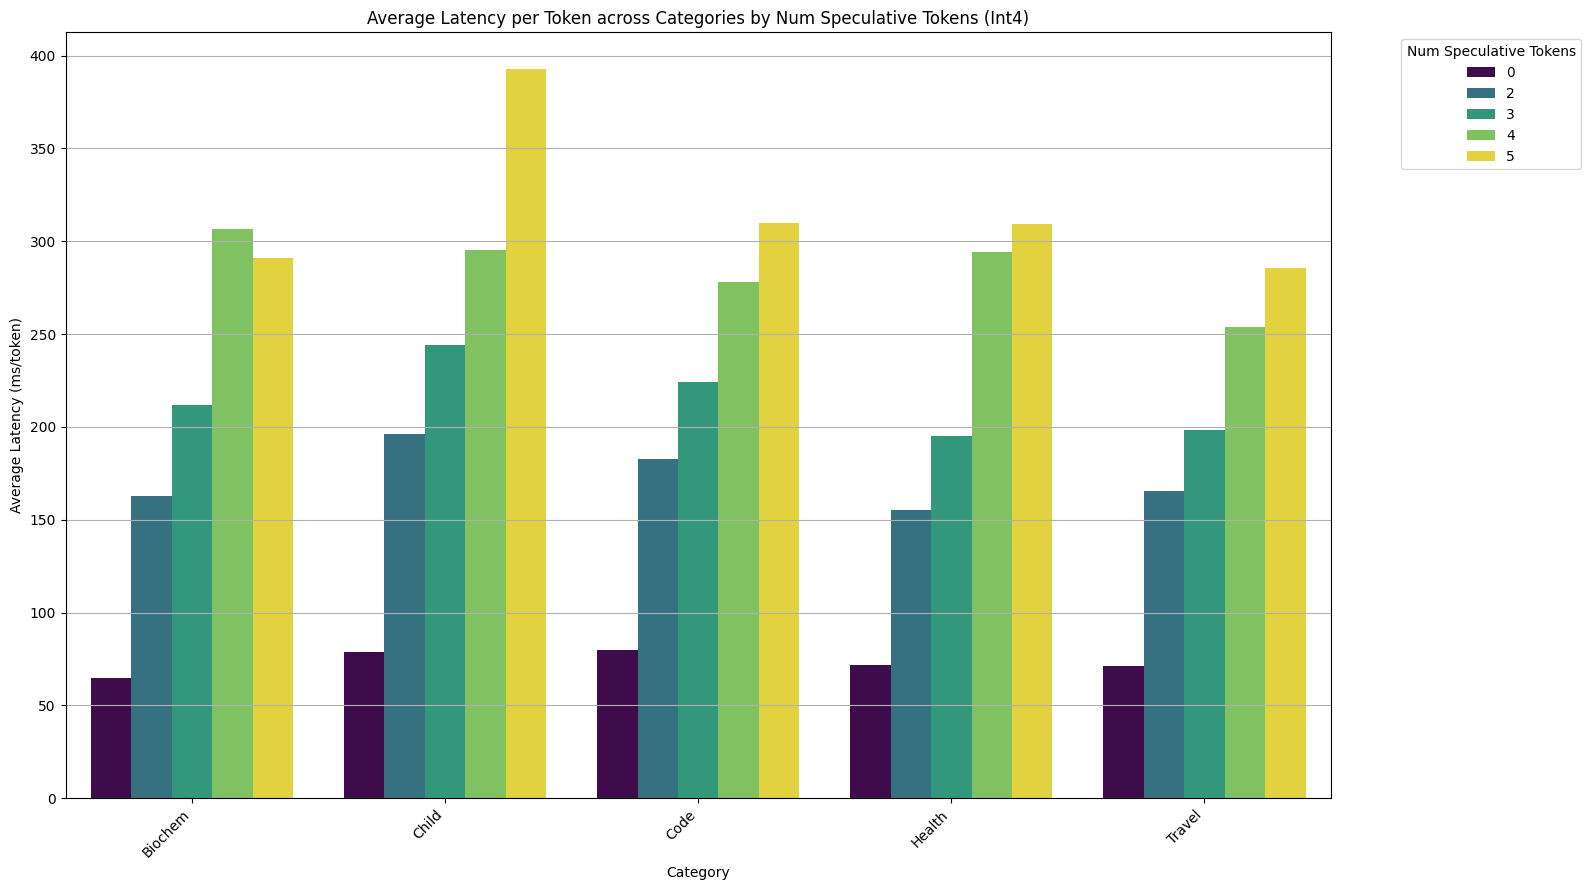

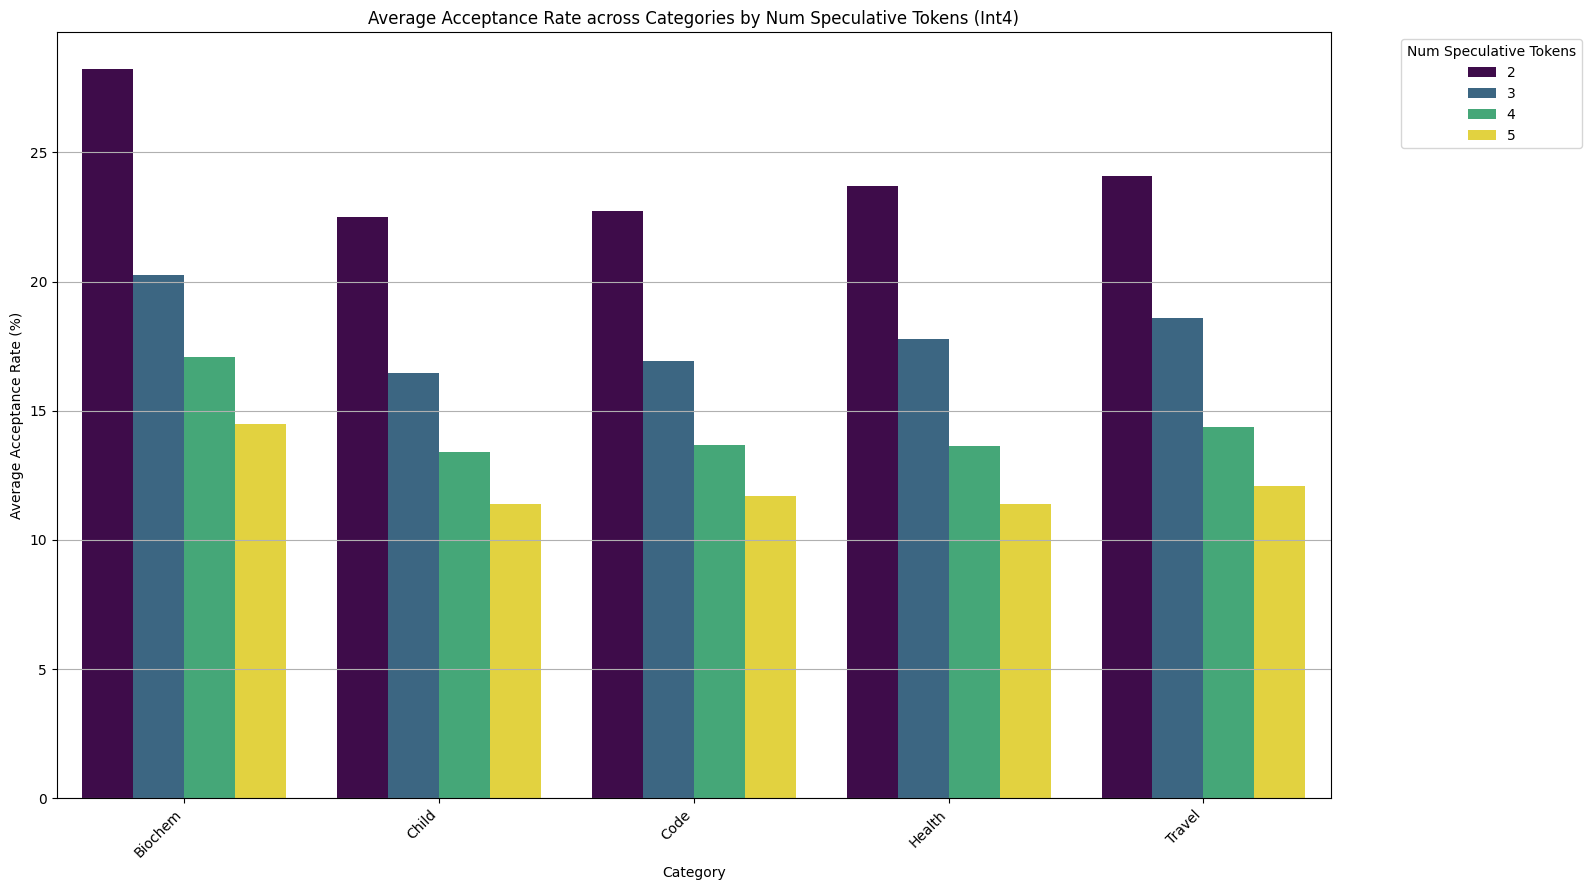

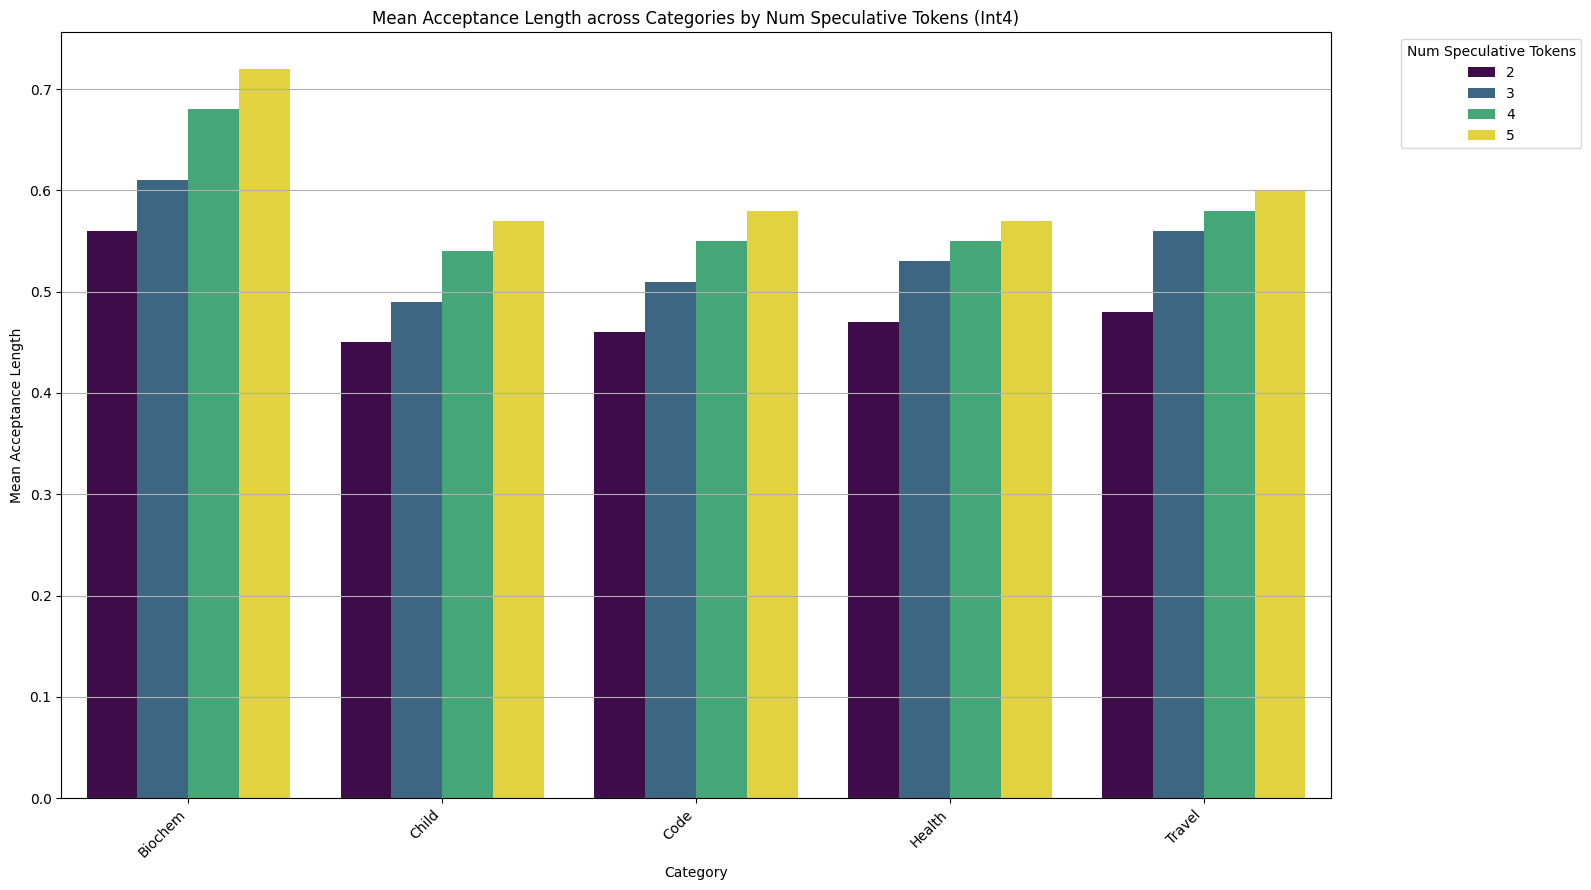


Further analysis and custom plots can be created using the 'int4_plot_df' DataFrame.
Index(['Experiment', 'Draft Model', 'Num Speculative Tokens', 'Category',
       'Latency (ms/token)', 'Acceptance rate', 'Avg Acceptance Length',
       'VRAM smi (GB)'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Assuming final_results_df is available from previous execution
# Filter for Int4 models only and Baseline
int4_filtered_results = final_results_df[
    final_results_df['Draft Model'].str.contains('Int4') |
    (final_results_df['Draft Model'] == 'N/A (Baseline)')
].copy()

# Group by relevant columns to get average metrics for plotting
int4_plot_df = int4_filtered_results.groupby(
    ['Experiment', 'Draft Model', 'Num Speculative Tokens', 'Category']
).agg({
    'Latency (ms/token)': 'mean',
    'Acceptance rate': 'mean',
    'Avg Acceptance Length': 'mean', # Added this metric
    'VRAM smi (GB)': 'mean'
}).reset_index()

int4_plot_df['Num Speculative Tokens'] = pd.to_numeric(int4_plot_df['Num Speculative Tokens'])

print("Aggregated Int8 data for plotting histograms:")
print(int4_plot_df.head())

# --- Bar Plot for Average Latency per Token across Categories by Num Speculative Tokens (Int4) ---
plt.figure(figsize=(16, 9))
sns.barplot(
    data=int4_plot_df,
    x='Category',
    y='Latency (ms/token)',
    hue='Num Speculative Tokens', # Use num_spec_tokens as hue for comparison
    palette='viridis'
)
plt.title('Average Latency per Token across Categories by Num Speculative Tokens (Int4)')
plt.xlabel('Category')
plt.ylabel('Average Latency (ms/token)')
plt.grid(axis='y')
plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Bar Plot for Average Acceptance Rate across Categories by Num Speculative Tokens (Int4) ---
plt.figure(figsize=(16, 9))
# Filter out baseline for acceptance rate as it's not applicable
int4_acceptance_plot_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0]
sns.barplot(
    data=int4_acceptance_plot_df,
    x='Category',
    y='Acceptance rate',
    hue='Num Speculative Tokens',
    palette='viridis'
)
plt.title('Average Acceptance Rate across Categories by Num Speculative Tokens (Int4)')
plt.xlabel('Category')
plt.ylabel('Average Acceptance Rate (%)')
plt.grid(axis='y')
plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Bar Plot for Mean Acceptance Length across Categories by Num Speculative Tokens (Int4) ---
plt.figure(figsize=(16, 9))
int4_mean_acceptance_length_plot_df = int4_plot_df[int4_plot_df['Num Speculative Tokens'] > 0]
sns.barplot(
    data=int4_mean_acceptance_length_plot_df,
    x='Category',
    y='Avg Acceptance Length',
    hue='Num Speculative Tokens',
    palette='viridis'
)
plt.title('Mean Acceptance Length across Categories by Num Speculative Tokens (Int4)')
plt.xlabel('Category')
plt.ylabel('Mean Acceptance Length')
plt.grid(axis='y')
plt.legend(title='Num Speculative Tokens', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFurther analysis and custom plots can be created using the 'int4_plot_df' DataFrame.")
print(int4_plot_df.columns)
